# TT3 Multivariate Gaussian DSP model

This notebook is the improved DSP baseline.
It loads the provided WAV/LAB files, keeps one complete training recording for validation,
fits a class-based VAD model, evaluates all four test recordings, and saves four required figures.

The test set never selects thresholds or model parameters.


In [1]:
from pathlib import Path
import json
import math
import wave

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display

np.set_printoptions(precision=5, suppress=True)
plt.rcParams.update({"figure.figsize": (12, 5), "axes.grid": True, "grid.alpha": 0.25})


In [2]:
def find_project_root():
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "TinHieuHuanLuyen").exists() and (candidate / "TinHieuKiemThu").exists():
            return candidate
    raise FileNotFoundError("Run this notebook inside the DSP midterm repository.")


def read_wav(path):
    with wave.open(str(path), "rb") as wav_file:
        channels = wav_file.getnchannels()
        sample_width = wav_file.getsampwidth()
        sample_rate = wav_file.getframerate()
        raw = wav_file.readframes(wav_file.getnframes())
    if sample_width != 2:
        raise ValueError(f"{path.name}: only 16-bit PCM is supported")
    signal = np.frombuffer(raw, dtype=np.int16).astype(np.float64)
    if channels > 1:
        signal = signal.reshape(-1, channels).mean(axis=1)
    return signal / 32768.0, sample_rate


def read_lab(path):
    segments = []
    for line in path.read_text(encoding="utf-8").splitlines():
        parts = line.split()
        if len(parts) < 3:
            continue
        try:
            start, end = float(parts[0]), float(parts[1])
        except ValueError:
            continue
        label = parts[2].lower()
        if label in {"sil", "v", "uv"}:
            segments.append((start, end, label))
    return segments


def load_records(root):
    records = []
    for split, folder in [("train", "TinHieuHuanLuyen"), ("test", "TinHieuKiemThu")]:
        for wav_path in sorted((root / folder).glob("*.wav")):
            signal, sample_rate = read_wav(wav_path)
            segments = read_lab(wav_path.with_suffix(".lab"))
            records.append({
                "name": wav_path.stem,
                "split": split,
                "signal": signal,
                "sample_rate": sample_rate,
                "segments": segments,
                "duration": len(signal) / sample_rate,
            })
    return records


ROOT = find_project_root()
RECORDS = load_records(ROOT)
print(f"Project root: {ROOT}")
for record in RECORDS:
    print(f"{record['split']:>5}  {record['name']:<10}  fs={record['sample_rate']:<5}  duration={record['duration']:.3f} s")


Project root: D:\DuyToan\DUT\Xử lý tín hiệu số\Midterm exam\K24
train  phone_F1    fs=16000  duration=3.240 s
train  phone_M1    fs=16000  duration=4.160 s
train  studio_F1   fs=44100  duration=2.863 s
train  studio_M1   fs=44100  duration=2.730 s
 test  phone_F2    fs=16000  duration=4.800 s
 test  phone_M2    fs=16000  duration=2.800 s
 test  studio_F2   fs=44100  duration=3.149 s
 test  studio_M2   fs=44100  duration=2.382 s


In [3]:
ALGORITHM = "TT3"
VARIANT = "2"
FRAME_MS = 20.0
HOP_MS = 10.0
MIN_SILENCE_MS = 200.0
OUTPUT_DIR = find_project_root() / "src" / ALGORITHM / "output" / VARIANT
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Output directory: {OUTPUT_DIR}")


Output directory: D:\DuyToan\DUT\Xử lý tín hiệu số\Midterm exam\K24\src\TT3\output\2


In [4]:
def frame_signal(signal, sample_rate, frame_ms=20.0, hop_ms=10.0):
    frame_length = int(round(frame_ms * sample_rate / 1000.0))
    hop_length = int(round(hop_ms * sample_rate / 1000.0))
    frame_count = max(1, int(np.ceil(max(0, len(signal) - frame_length) / hop_length)) + 1)
    padded_length = (frame_count - 1) * hop_length + frame_length
    padded = np.zeros(padded_length, dtype=np.float64)
    padded[:len(signal)] = signal
    frames = np.zeros((frame_count, frame_length), dtype=np.float64)
    for index in range(frame_count):
        start = index * hop_length
        frames[index] = padded[start:start + frame_length]
    starts = np.arange(frame_count) * hop_length / sample_rate
    centers = starts + frame_length / (2.0 * sample_rate)
    return frames, starts, centers


def pre_emphasis(signal, coefficient=0.97):
    output = np.empty_like(signal)
    output[0] = signal[0]
    output[1:] = signal[1:] - coefficient * signal[:-1]
    return output


def compute_features(signal, sample_rate, frame_ms=20.0, hop_ms=10.0):
    frames, starts, centers = frame_signal(signal, sample_rate, frame_ms, hop_ms)
    emphasized, _, _ = frame_signal(pre_emphasis(signal), sample_rate, frame_ms, hop_ms)
    window = np.hamming(frames.shape[1])
    ste_raw = np.mean(frames ** 2, axis=1)
    ste_norm = ste_raw / max(float(ste_raw.max()), 1e-12)
    emphasized_energy = np.mean(emphasized ** 2, axis=1)
    emphasized_norm = emphasized_energy / max(float(emphasized_energy.max()), 1e-12)
    zcr = np.mean(np.abs(np.diff(np.signbit(emphasized), axis=1)), axis=1)
    spectrum = np.abs(np.fft.rfft(emphasized * window, axis=1)) ** 2
    frequencies = np.fft.rfftfreq(frames.shape[1], d=1.0 / sample_rate)
    high_mask = frequencies >= 3000.0
    high_ratio = spectrum[:, high_mask].sum(axis=1) / np.maximum(spectrum.sum(axis=1), 1e-12)
    log_energy = np.log10(ste_raw + 1e-12)

    # A simple autocorrelation pitch track for the result figure.
    # It is not used by the VAD classifier.
    f0 = np.full(len(frames), np.nan)
    min_lag = max(1, sample_rate // 350)
    max_lag = min(frames.shape[1] - 1, sample_rate // 70)
    for index, frame in enumerate(frames):
        centered = (frame - frame.mean()) * window
        correlation = np.correlate(centered, centered, mode="full")[len(centered) - 1:]
        if correlation[0] <= 1e-12 or ste_norm[index] < 0.01:
            continue
        lag = min_lag + int(np.argmax(correlation[min_lag:max_lag + 1]))
        if correlation[lag] / correlation[0] >= 0.30:
            f0[index] = sample_rate / lag
    return {
        "frames": frames,
        "starts": starts,
        "centers": centers,
        "ste_raw": ste_raw,
        "ste_norm": ste_norm,
        "log_energy": log_energy,
        "emphasized_norm": emphasized_norm,
        "zcr": zcr,
        "high_ratio": high_ratio,
        "f0": f0,
    }


def frame_labels(centers, segments):
    labels = np.full(len(centers), "sil", dtype="<U3")
    for index, time_value in enumerate(centers):
        for start, end, label in segments:
            if start <= time_value < end or (index == len(centers) - 1 and start <= time_value <= end):
                labels[index] = label
                break
    return labels


def speech_bounds(segments):
    speech = [(start, end) for start, end, label in segments if label in {"v", "uv"}]
    return min(start for start, _ in speech), max(end for _, end in speech)


def bridge_short_silences(decisions, hop_ms=10.0, minimum_ms=200.0):
    output = np.asarray(decisions, dtype=np.int8).copy()
    minimum_frames = int(round(minimum_ms / hop_ms))
    speech_indices = np.flatnonzero(output)
    if len(speech_indices) == 0:
        return output
    index = int(speech_indices[0])
    last = int(speech_indices[-1])
    while index <= last:
        if output[index] == 1:
            index += 1
            continue
        start = index
        while index <= last and output[index] == 0:
            index += 1
        if index - start < minimum_frames:
            output[start:index] = 1
    return output


def decisions_to_bounds(decisions, starts, duration, frame_ms=20.0):
    indices = np.flatnonzero(decisions)
    if len(indices) == 0:
        return 0.0, 0.0
    start = float(starts[indices[0]])
    end = min(duration, float(starts[indices[-1]] + frame_ms / 1000.0))
    return round(start, 4), round(end, 4)


def prepare_records(records):
    prepared = []
    for record in records:
        item = dict(record)
        item["features"] = compute_features(item["signal"], item["sample_rate"], FRAME_MS, HOP_MS)
        item["labels"] = frame_labels(item["features"]["centers"], item["segments"])
        item["targets"] = np.isin(item["labels"], ["v", "uv"]).astype(np.int8)
        item["ground_truth"] = speech_bounds(item["segments"])
        prepared.append(item)
    return prepared


DATA = prepare_records(RECORDS)
print(f"Prepared {len(DATA)} recordings with 20 ms frames and 10 ms hops")


Prepared 8 recordings with 20 ms frames and 10 ms hops


In [5]:
TRAIN_RECORDS = [record for record in DATA if record["split"] == "train"]
TEST_RECORDS = [record for record in DATA if record["split"] == "test"]

# One whole recording is held out. Frames from the same recording never cross the split.
VALIDATION_NAME = "studio_M1"
FIT_RECORDS = [record for record in TRAIN_RECORDS if record["name"] != VALIDATION_NAME]
VALIDATION_RECORDS = [record for record in TRAIN_RECORDS if record["name"] == VALIDATION_NAME]

print("Fit recordings:", [record["name"] for record in FIT_RECORDS])
print("Validation recording:", [record["name"] for record in VALIDATION_RECORDS])
print("Final test recordings:", [record["name"] for record in TEST_RECORDS])


Fit recordings: ['phone_F1', 'phone_M1', 'studio_F1']
Validation recording: ['studio_M1']
Final test recordings: ['phone_F2', 'phone_M2', 'studio_F2', 'studio_M2']


In [6]:
class MultivariateGaussianVAD:
    """Full-covariance Gaussian classifier over energy, ZCR, and spectrum features."""

    def __init__(self, regularization=0.08):
        self.regularization = regularization
        self.mean_ = None
        self.std_ = None
        self.class_models_ = {}
        self.history_ = []

    @staticmethod
    def _raw_matrix(record):
        features = record["features"]
        return np.column_stack([
            features["log_energy"],
            features["emphasized_norm"],
            features["zcr"],
            features["high_ratio"],
        ])

    @staticmethod
    def _log_pdf(matrix, mean, covariance):
        inverse = np.linalg.inv(covariance)
        _, log_det = np.linalg.slogdet(covariance)
        centered = matrix - mean
        quadratic = np.einsum("ij,jk,ik->i", centered, inverse, centered)
        return -0.5 * (matrix.shape[1] * np.log(2*np.pi) + log_det + quadratic)

    def fit(self, records):
        matrix = np.vstack([self._raw_matrix(record) for record in records])
        targets = np.concatenate([record["targets"] for record in records])
        self.mean_ = matrix.mean(axis=0)
        self.std_ = np.maximum(matrix.std(axis=0), 1e-8)
        x = (matrix - self.mean_) / self.std_
        self.class_models_ = {}
        for label in [0, 1]:
            subset = x[targets == label]
            mean = subset.mean(axis=0)
            covariance = np.cov(subset, rowvar=False) + self.regularization * np.eye(x.shape[1])
            self.class_models_[label] = (mean, covariance)
        score_silence = self._log_pdf(x, *self.class_models_[0])
        score_speech = self._log_pdf(x, *self.class_models_[1])
        selected = np.where(targets == 1, score_speech, score_silence)
        self.history_ = [{"step": 1, "negative_log_likelihood": float(-selected.mean()), "regularization": self.regularization}]
        return self

    def predict(self, record):
        matrix = (self._raw_matrix(record) - self.mean_) / self.std_
        scores = self._log_pdf(matrix, *self.class_models_[1]) - self._log_pdf(matrix, *self.class_models_[0])
        decisions = bridge_short_silences(scores >= 0.0, HOP_MS, MIN_SILENCE_MS)
        return decisions, scores

    def describe(self):
        return {
            "name": self.__class__.__name__,
            "features": ["log STE", "pre-emphasized STE", "ZCR", "high-frequency energy ratio"],
            "fir_kernel": [1.0, -0.97],
            "regularization": self.regularization,
        }


In [7]:
def boundary_errors(predicted, truth):
    delta = (np.asarray(predicted) - np.asarray(truth)) * 1000.0
    mae = float(np.mean(np.abs(delta)))
    rmse = float(np.sqrt(np.mean(delta ** 2)))
    return delta, mae, rmse


def classification_metrics(decisions, labels):
    truth = np.isin(labels, ["v", "uv"]).astype(np.int8)
    tp = int(np.sum((decisions == 1) & (truth == 1)))
    fp = int(np.sum((decisions == 1) & (truth == 0)))
    fn = int(np.sum((decisions == 0) & (truth == 1)))
    precision = tp / max(tp + fp, 1)
    recall = tp / max(tp + fn, 1)
    f1 = 2 * precision * recall / max(precision + recall, 1e-12)
    uv_mask = labels == "uv"
    uv_recall = float(np.mean(decisions[uv_mask] == 1)) if np.any(uv_mask) else float("nan")
    return precision, recall, f1, uv_recall


def evaluate_model(model, records):
    rows = []
    predictions = {}
    for record in records:
        decisions, score = model.predict(record)
        predicted = decisions_to_bounds(decisions, record["features"]["starts"], record["duration"], FRAME_MS)
        delta, mae, rmse = boundary_errors(predicted, record["ground_truth"])
        precision, recall, f1, uv_recall = classification_metrics(decisions, record["labels"])
        rows.append({
            "file": record["name"],
            "gt_start": record["ground_truth"][0],
            "gt_end": record["ground_truth"][1],
            "pred_start": predicted[0],
            "pred_end": predicted[1],
            "delta_start_ms": float(delta[0]),
            "delta_end_ms": float(delta[1]),
            "mae_ms": mae,
            "rmse_ms": rmse,
            "frame_f1": f1,
            "uv_recall": uv_recall,
        })
        predictions[record["name"]] = (decisions, score)
    summary = {
        "mean_mae_ms": float(np.mean([row["mae_ms"] for row in rows])),
        "mean_rmse_ms": float(np.mean([row["rmse_ms"] for row in rows])),
        "mean_frame_f1": float(np.mean([row["frame_f1"] for row in rows])),
        "mean_uv_recall": float(np.nanmean([row["uv_recall"] for row in rows])),
    }
    return rows, summary, predictions


def print_results(rows, summary):
    print(f"{'File':<11} {'Ground truth':<16} {'Prediction':<16} {'MAE ms':>8} {'RMSE ms':>9} {'F1':>7} {'UV recall':>10}")
    for row in rows:
        truth = f"[{row['gt_start']:.2f}, {row['gt_end']:.2f}]"
        prediction = f"[{row['pred_start']:.2f}, {row['pred_end']:.2f}]"
        print(f"{row['file']:<11} {truth:<16} {prediction:<16} {row['mae_ms']:>8.2f} {row['rmse_ms']:>9.2f} {row['frame_f1']:>7.3f} {row['uv_recall']:>10.3f}")
    print("Summary:", json.dumps(summary, indent=2))


def save_results(rows, summary, model):
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    payload = {
        "algorithm": ALGORITHM,
        "variant": VARIANT,
        "model": model.describe(),
        "history": model.history_,
        "summary": summary,
        "files": rows,
    }
    (OUTPUT_DIR / "metrics.json").write_text(json.dumps(payload, indent=2), encoding="utf-8")
    return payload


In [8]:
MODEL = MultivariateGaussianVAD(regularization=0.08)
MODEL.fit(FIT_RECORDS)
print("Training history:")
for item in MODEL.history_:
    print(item)


Training history:
{'step': 1, 'negative_log_likelihood': 3.9899023702717225, 'regularization': 0.08}


In [9]:
VALIDATION_ROWS, VALIDATION_SUMMARY, _ = evaluate_model(MODEL, VALIDATION_RECORDS)
print("Validation result")
print_results(VALIDATION_ROWS, VALIDATION_SUMMARY)

# Refit only after the validation check. The final model uses all four training recordings.
FINAL_MODEL = MultivariateGaussianVAD(regularization=0.08)
FINAL_MODEL.fit(TRAIN_RECORDS)
print("Final model:", FINAL_MODEL.describe())


Validation result
File        Ground truth     Prediction         MAE ms   RMSE ms      F1  UV recall
studio_M1   [0.87, 2.06]     [0.91, 2.05]        25.00     29.15   0.970      0.800
Summary: {
  "mean_mae_ms": 25.000000000000135,
  "mean_rmse_ms": 29.154759474226566,
  "mean_frame_f1": 0.9699570815450643,
  "mean_uv_recall": 0.8
}
Final model: {'name': 'MultivariateGaussianVAD', 'features': ['log STE', 'pre-emphasized STE', 'ZCR', 'high-frequency energy ratio'], 'fir_kernel': [1.0, -0.97], 'regularization': 0.08}


In [10]:
TEST_ROWS, TEST_SUMMARY, TEST_PREDICTIONS = evaluate_model(FINAL_MODEL, TEST_RECORDS)
print_results(TEST_ROWS, TEST_SUMMARY)
RESULT_PAYLOAD = save_results(TEST_ROWS, TEST_SUMMARY, FINAL_MODEL)


File        Ground truth     Prediction         MAE ms   RMSE ms      F1  UV recall
phone_F2    [1.02, 4.04]     [1.07, 4.01]        40.00     41.23   0.935      0.742
phone_M2    [0.53, 2.52]     [0.53, 2.51]         5.00      7.07   0.992      0.970
studio_F2   [0.77, 2.37]     [0.76, 2.37]         5.00      7.07   0.997      1.000
studio_M2   [0.45, 1.93]     [0.46, 1.92]        10.00     10.00   0.990      0.900
Summary: {
  "mean_mae_ms": 15.000000000000068,
  "mean_rmse_ms": 16.343297969976962,
  "mean_frame_f1": 0.9784583550918231,
  "mean_uv_recall": 0.9031433740388964
}


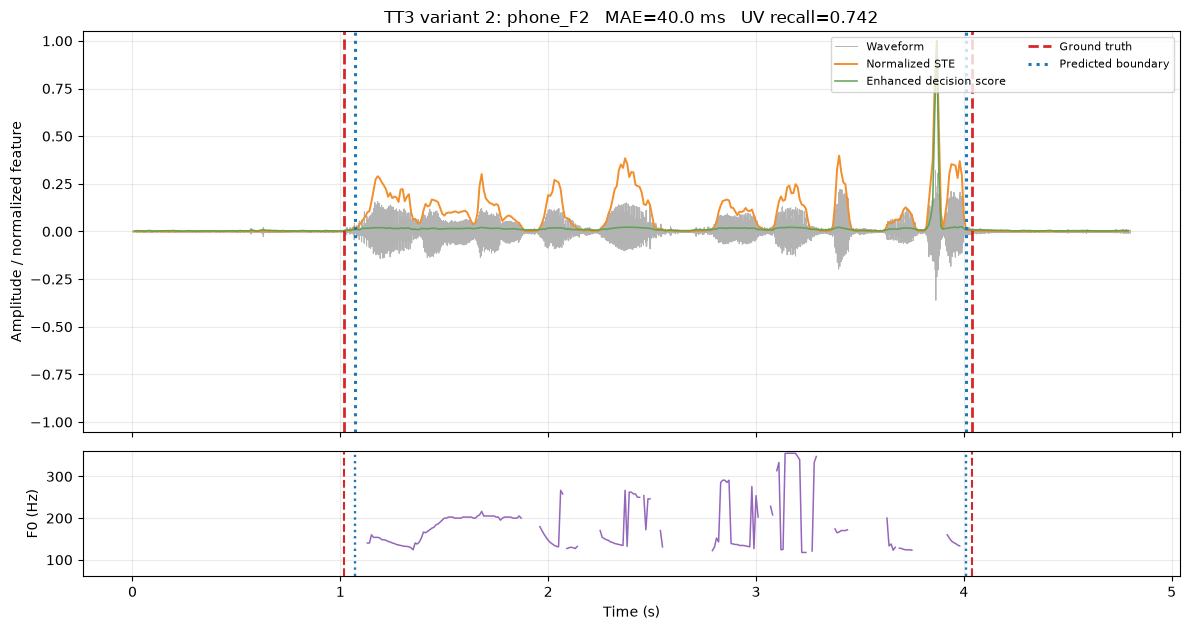

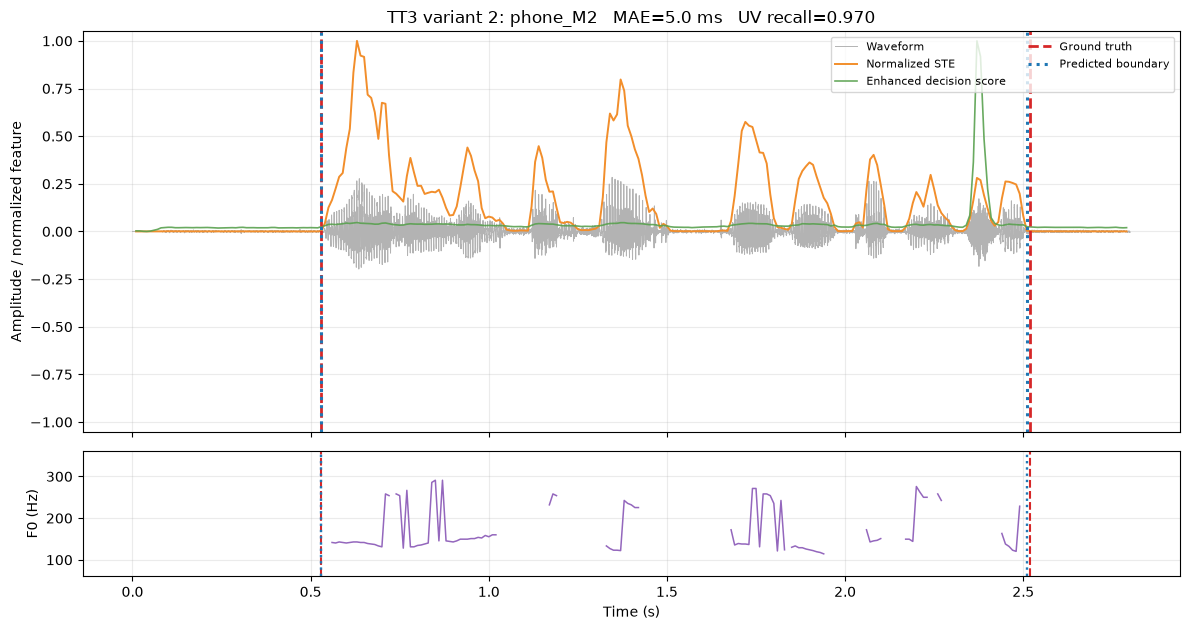

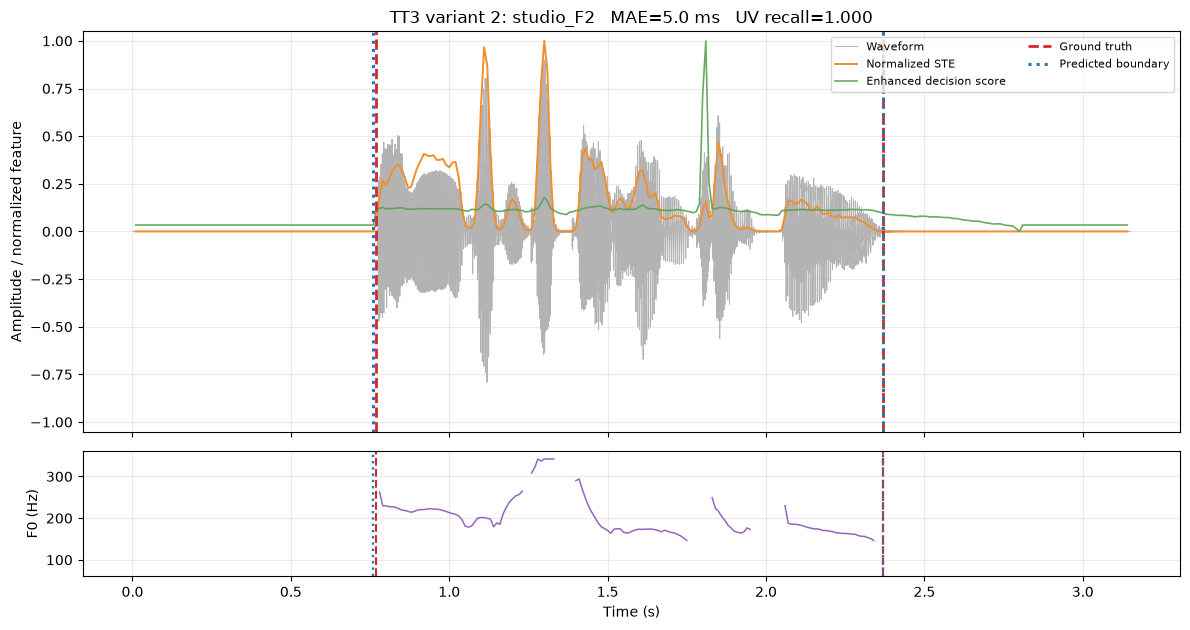

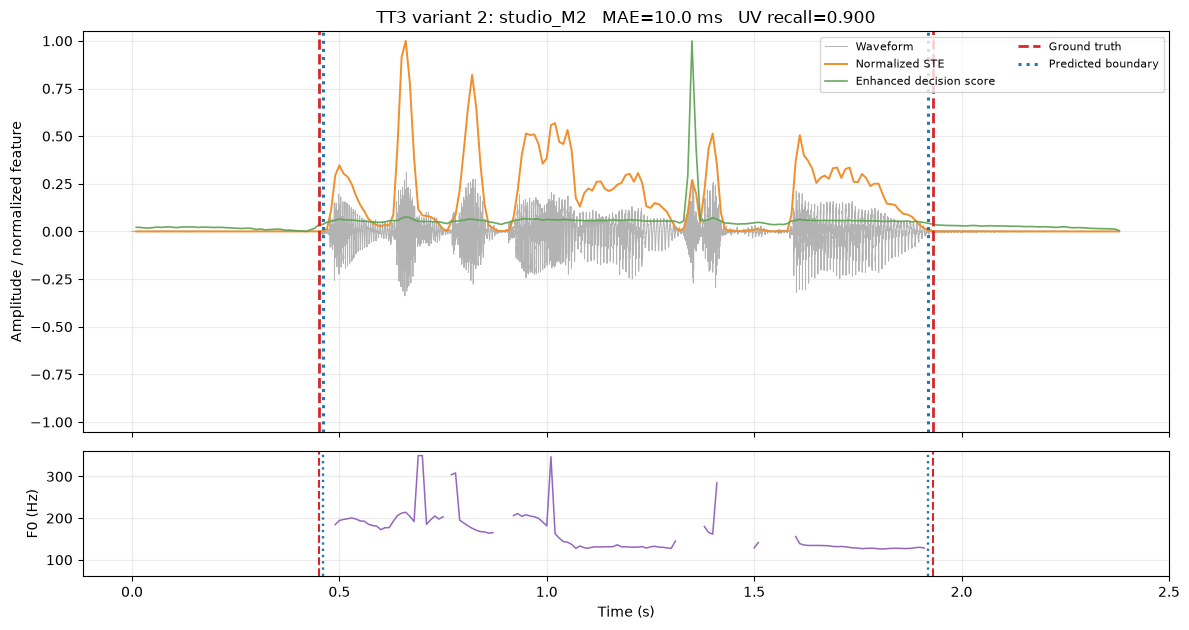

Saved figures and metrics to D:\DuyToan\DUT\Xử lý tín hiệu số\Midterm exam\K24\src\TT3\output\2


In [11]:
def plot_results(model, records, rows, predictions):
    row_by_name = {row["file"]: row for row in rows}
    for record in records:
        row = row_by_name[record["name"]]
        decisions, score = predictions[record["name"]]
        time_axis = np.arange(len(record["signal"])) / record["sample_rate"]
        feature_time = record["features"]["centers"]
        score_array = np.asarray(score, dtype=float)
        if np.ptp(score_array) > 1e-12:
            score_display = (score_array - score_array.min()) / np.ptp(score_array)
        else:
            score_display = np.zeros_like(score_array)
        fig, (ax, pitch_ax) = plt.subplots(
            2, 1, figsize=(12, 6.4), sharex=True,
            gridspec_kw={"height_ratios": [3.2, 1.0]},
        )
        ax.plot(time_axis, record["signal"], color="0.70", linewidth=0.7, label="Waveform")
        ax.plot(feature_time, record["features"]["ste_norm"], color="#f28e2b", linewidth=1.4, label="Normalized STE")
        if VARIANT == "2":
            ax.plot(feature_time, score_display, color="#59a14f", linewidth=1.2, alpha=0.9, label="Enhanced decision score")
        gt_start, gt_end = record["ground_truth"]
        ax.axvline(gt_start, color="#d62728", linestyle="--", linewidth=2.0, label="Ground truth")
        ax.axvline(gt_end, color="#d62728", linestyle="--", linewidth=2.0)
        ax.axvline(row["pred_start"], color="#1f77b4", linestyle=":", linewidth=2.2, label="Predicted boundary")
        ax.axvline(row["pred_end"], color="#1f77b4", linestyle=":", linewidth=2.2)
        ax.set_title(f"{ALGORITHM} variant {VARIANT}: {record['name']}   MAE={row['mae_ms']:.1f} ms   UV recall={row['uv_recall']:.3f}")
        ax.set_ylabel("Amplitude / normalized feature")
        ax.set_ylim(-1.05, 1.05)
        ax.legend(loc="upper right", ncol=2, fontsize=8)

        pitch_ax.plot(feature_time, record["features"]["f0"], color="#9467bd", linewidth=1.1)
        pitch_ax.axvline(gt_start, color="#d62728", linestyle="--", linewidth=1.5)
        pitch_ax.axvline(gt_end, color="#d62728", linestyle="--", linewidth=1.5)
        pitch_ax.axvline(row["pred_start"], color="#1f77b4", linestyle=":", linewidth=1.7)
        pitch_ax.axvline(row["pred_end"], color="#1f77b4", linestyle=":", linewidth=1.7)
        pitch_ax.set_xlabel("Time (s)")
        pitch_ax.set_ylabel("F0 (Hz)")
        pitch_ax.set_ylim(60, 360)
        pitch_ax.grid(alpha=0.25)
        fig.tight_layout()
        path = OUTPUT_DIR / f"{record['name']}.png"
        fig.savefig(path, dpi=160, bbox_inches="tight")
        display(fig)
        plt.close(fig)


plot_results(FINAL_MODEL, TEST_RECORDS, TEST_ROWS, TEST_PREDICTIONS)
print(f"Saved figures and metrics to {OUTPUT_DIR}")


## Interpretation guide

- STE tracks high-energy voiced speech.
- ZCR and the pre-emphasis filter help retain weak unvoiced consonants.
- Red vertical lines show the LAB ground truth. Blue dotted lines show the estimated boundaries.
- Boundary MAE and RMSE use milliseconds. Frame F1 and UV recall provide supporting evidence.
